# Student Performance Analysis

## Pluto Academy Data Analytics Internship

### Project 2

Prepared by:
Kavya

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
students = pd.read_csv("StudentsPerformance.csv")

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Shape of Dataset:")
print(students.shape)

Shape of Dataset:
(1000, 8)


In [4]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
print(students.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [6]:
print(students.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [7]:
students.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [8]:
print("Duplicate Rows:", students.duplicated().sum())

Duplicate Rows: 0


In [9]:
students = students.drop_duplicates()

print("Duplicates removed successfully!")

Duplicates removed successfully!


In [10]:
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Data Cleaning Decisions

1. Loaded the dataset using Pandas.
2. Checked the dataset shape and data types.
3. Verified that there were no missing values.
4. Checked for duplicate records and removed them if present.
5. Explored summary statistics using `describe()`.

# Dataset Summary

This dataset contains information about student performance in mathematics, reading, and writing. It also includes demographic and educational factors such as gender, race/ethnicity, parental level of education, lunch type, and test preparation course completion. The dataset contains academic scores for each student. It is useful for understanding factors that influence student performance. The analysis helps identify patterns and students who may require additional academic support.

In [11]:
students["Total Score"] = (
    students["math score"] +
    students["reading score"] +
    students["writing score"]
)

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [12]:
parent_scores = students.groupby("parental level of education")[["math score","reading score","writing score"]].mean()

parent_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


<Figure size 1000x600 with 0 Axes>

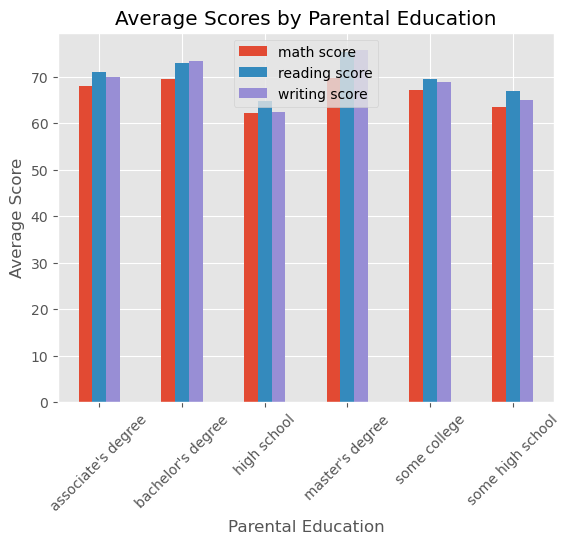

In [13]:
plt.figure(figsize=(10,6))

parent_scores.plot(kind="bar")

plt.title("Average Scores by Parental Education")

plt.xlabel("Parental Education")

plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.show()

In [14]:
prep_scores = students.groupby("test preparation course")[["math score","reading score","writing score"]].mean()

prep_scores

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


<Figure size 800x500 with 0 Axes>

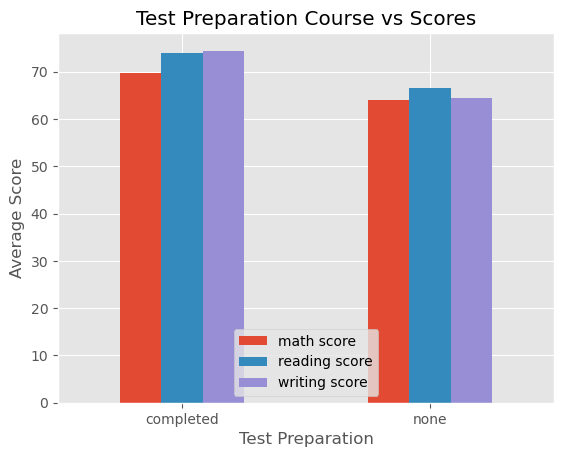

In [15]:
plt.figure(figsize=(8,5))

prep_scores.plot(kind="bar")

plt.title("Test Preparation Course vs Scores")

plt.xlabel("Test Preparation")

plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

In [16]:
correlation = students[["math score","reading score","writing score"]].corr()

correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


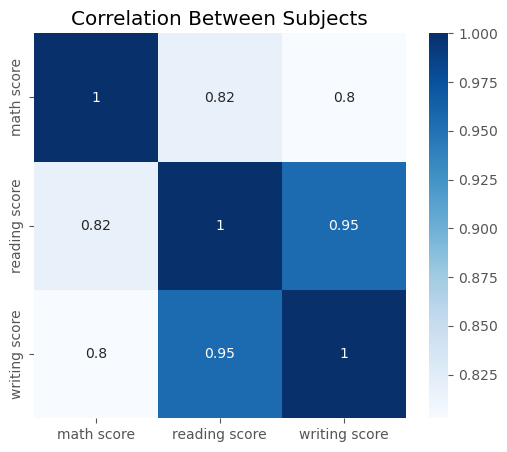

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(correlation, annot=True, cmap="Blues")

plt.title("Correlation Between Subjects")

plt.show()

In [18]:
gender_scores = students.groupby("gender")[["math score","reading score","writing score"]].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


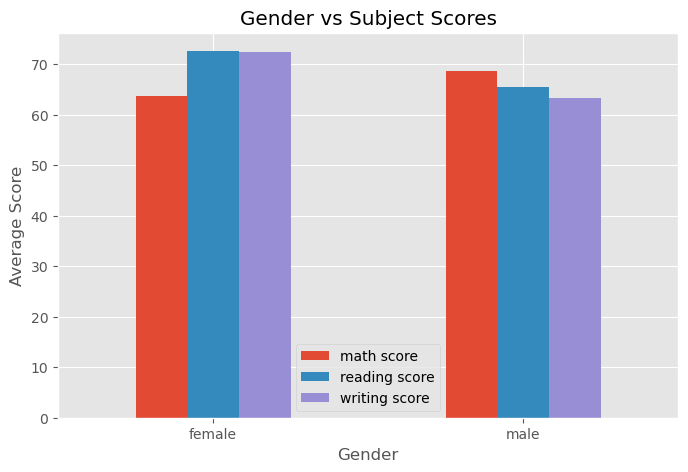

In [19]:
gender_scores.plot(kind="bar", figsize=(8,5))

plt.title("Gender vs Subject Scores")

plt.xlabel("Gender")

plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

In [20]:
students["Total Score"].describe()

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: Total Score, dtype: float64

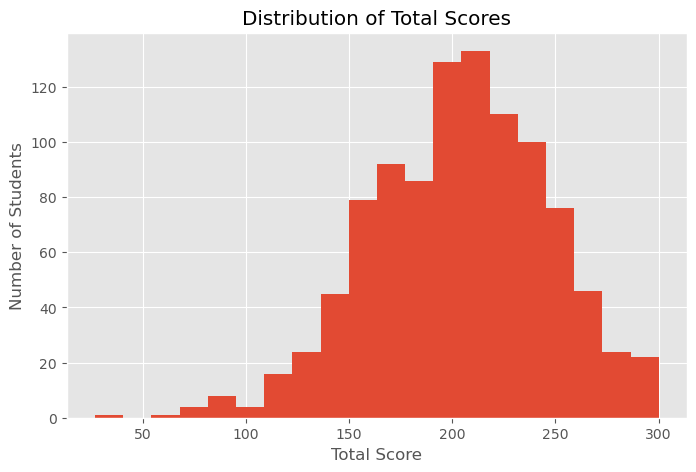

In [21]:
plt.figure(figsize=(8,5))

plt.hist(students["Total Score"], bins=20)

plt.title("Distribution of Total Scores")

plt.xlabel("Total Score")

plt.ylabel("Number of Students")

plt.show()

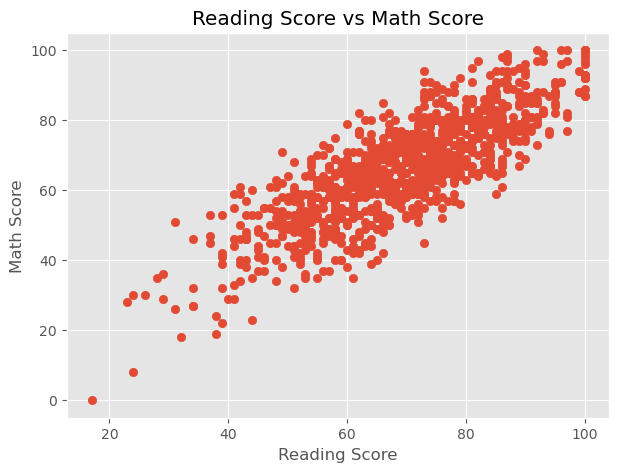

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(students["reading score"], students["math score"])

plt.title("Reading Score vs Math Score")

plt.xlabel("Reading Score")

plt.ylabel("Math Score")

plt.show()

In [23]:
students["At Risk"] = (
    (students["math score"] < 50) |
    (students["reading score"] < 50) |
    (students["writing score"] < 50)
)

students[["math score","reading score","writing score","At Risk"]].head()

,math score,reading score,writing score,At Risk
0,72,72,74,False
1,69,90,88,False
2,90,95,93,False
3,47,57,44,True
4,76,78,75,False


In [24]:
print("Total Students:", len(students))

print("At-Risk Students:", students["At Risk"].sum())

Total Students: 1000
At-Risk Students: 188


In [25]:
risk_gender = students.groupby("gender")["At Risk"].mean()*100

risk_gender

gender
female    17.181467
male      20.539419
Name: At Risk, dtype: float64

In [26]:
risk_parent = students.groupby("parental level of education")["At Risk"].mean()*100

risk_parent

parental level of education
associate's degree    14.864865
bachelor's degree     13.559322
high school           25.000000
master's degree       10.169492
some college          16.814159
some high school      25.698324
Name: At Risk, dtype: float64

In [27]:
risk_table = students.groupby(
    ["gender","parental level of education"]
)["At Risk"].agg(["count","sum"])

risk_table.rename(
    columns={
        "count":"Total Students",
        "sum":"At Risk Students"
    },
    inplace=True
)

risk_table

Total Students  At Risk Students
gender parental level of education                                  
female associate's degree                      116                15
       bachelor's degree                        63                 8
       high school                              94                21
       master's degree                          36                 4
       some college                            118                14
       some high school                         91                27
male   associate's degree                      106                18
       bachelor's degree                        55                 8
       high school                             102                28
       master's degree                          23                 2
       some college                            108                24
       some high school                         88                19

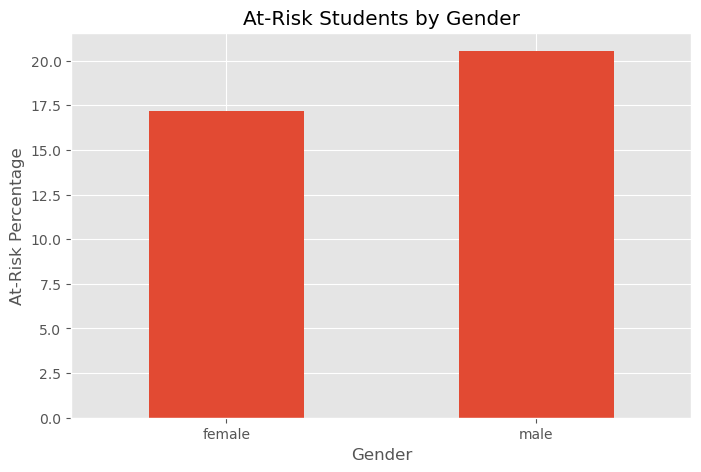

In [28]:
plt.figure(figsize=(8,5))

risk_gender.plot(kind="bar")

plt.title("At-Risk Students by Gender")

plt.xlabel("Gender")

plt.ylabel("At-Risk Percentage")

plt.xticks(rotation=0)

plt.show()

# Principal's Report

## Executive Summary

This analysis examined student performance using mathematics, reading, and writing scores along with demographic and educational factors. The study identified factors that influence academic performance and highlighted students who may require additional academic support. The findings can help the school improve student outcomes through targeted interventions.

## Key Findings

1. Students who completed the test preparation course scored higher on average in all subjects.
2. Higher parental education levels were generally associated with better student performance.
3. Reading and writing scores showed a strong positive correlation.
4. Female students generally performed better in reading and writing, while male students performed similarly or slightly better in mathematics.
5. A significant number of students were identified as at-risk because they scored below 50 in at least one subject.

## Recommendations

1. Encourage all students to complete the test preparation course before examinations.
2. Provide additional tutoring and mentoring programs for at-risk students.
3. Organize regular parent engagement sessions to encourage academic support at home.

# Most Impactful Recommendation

The most impactful recommendation is to provide additional tutoring and mentoring for at-risk students. Early academic support can improve student confidence, strengthen subject knowledge, and reduce the number of students performing below the expected level. This targeted intervention can significantly improve overall school performance.

# Data Cleaning Decisions

1. Loaded the dataset using Pandas.
2. Checked the dataset shape and data types.
3. Verified that there were no missing values.
4. Checked and removed duplicate records.
5. Created a new Total Score column.
6. Created an At-Risk column based on scores below 50 in any subject.

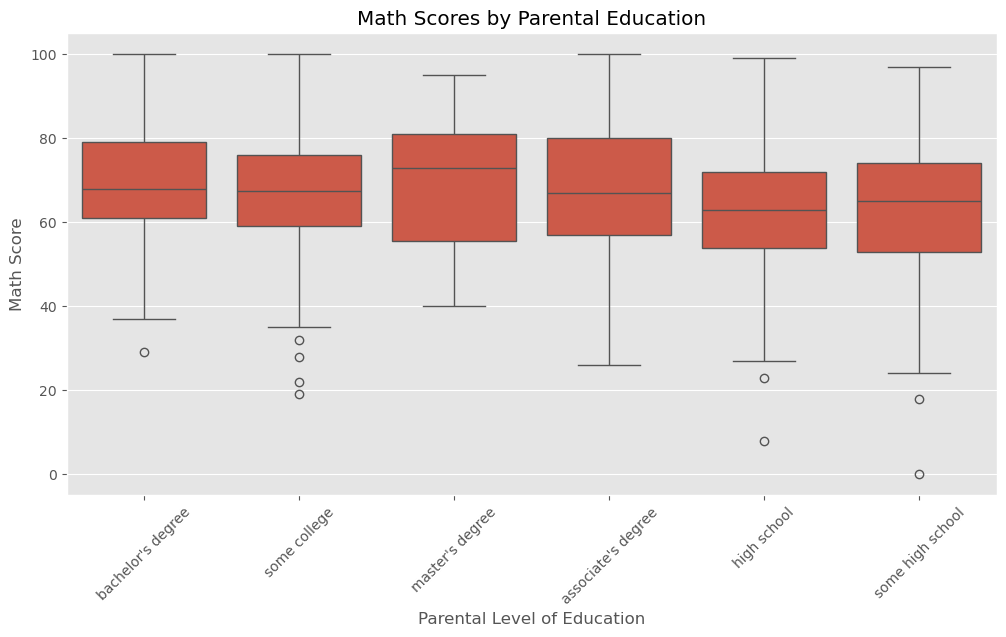

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="parental level of education",
    y="math score",
    data=students
)

plt.title("Math Scores by Parental Education")

plt.xlabel("Parental Level of Education")

plt.ylabel("Math Score")

plt.xticks(rotation=45)

plt.show()

# At-Risk Student Explanation

Students scoring below 50 in at least one subject were classified as at-risk. These students may require additional academic support, mentoring, or tutoring. The segmentation helps the school identify groups that need focused intervention and improve overall student performance.